# 07 - Choosing priors

**Goal.** Treat the prior as a modelling decision that can be made well or badly. We
turn an expert's statements into a prior, look at "non-informative" and improper
priors and the trap that flat is not the same as uninformative, derive Jeffreys
priors from the Fisher information, use prior predictive checks to catch absurd
priors, and finish with a sensitivity analysis: the habit of showing how much the
conclusion depends on the prior.

## 1. Where priors come from

A prior summarises what is known about a parameter before the current data. In
practice it comes from one or more of:

- **previous data**: earlier studies, historical records, a pilot experiment;
- **expert knowledge**: people who know the domain, asked carefully [4];
- **structure**: physical limits (a rate is positive, a probability is in $[0,1]$),
  plausible orders of magnitude;
- **convenience**: a conjugate family, chosen because it is easy to update, with
  hyperparameters set to match the knowledge above.

Two properties of the posterior make this less fraught than it first seems. With
enough data the likelihood dominates any reasonable prior (chapters 04-06 showed the
prior's weight shrinking like $1/n$). And the prior is written down explicitly, so it
can be criticised, which is more than can be said for many implicit choices in data
analysis.

## 2. Turning an expert's statements into a prior

A product manager says of a new feature: "I'd guess about 20% of users will adopt it,
and I'd be very surprised, maybe one chance in ten, if it were more than 40%." That is
two statements: a **mode** of 0.2 and a **90th percentile** of 0.4. A beta prior has
two parameters, so two statements pin it down.

The mode of Beta$(\alpha,\beta)$ is $(\alpha-1)/(\alpha+\beta-2)$. Setting it to 0.2 gives
$\beta = 4\alpha-3$, leaving one unknown, $\alpha$, which we choose so that the 90th
percentile is 0.4. That is a one-dimensional root-finding problem.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, optimize, integrate

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (7.5, 3.4), "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})
PRIOR, LIK, POST = "#8a949e", "#eb6834", "#2a78d6"
rng = np.random.default_rng(7)

def gap(a):
    return stats.beta.ppf(0.9, a, 4 * a - 3) - 0.4

a = optimize.brentq(gap, 1.01, 50)
b = 4 * a - 3
prior = stats.beta(a, b)
print(f"elicited prior: Beta({a:.2f}, {b:.2f})")
print(f"check: mode {(a - 1) / (a + b - 2):.3f}, P(θ > 0.4) = {prior.sf(0.4):.3f}, mean {prior.mean():.3f}, "
      f"worth about {a + b:.1f} observations")
print(f"central 95% of the prior: ({prior.ppf(0.025):.3f}, {prior.ppf(0.975):.3f})")

elicited prior: Beta(3.28, 10.12)
check: mode 0.200, P(θ > 0.4) = 0.100, mean 0.245, worth about 13.4 observations
central 95% of the prior: (0.064, 0.497)


Always **feed the result back** to the expert in their own terms: "so you are saying
there is a 2.5% chance adoption is below 6%, and the prior is worth about as much as
watching a dozen users?" If that sounds wrong to them, the prior is wrong, whatever
the equations say.

## 3. Flat priors and improper priors

When little is known, a natural idea is a **flat** prior, $p(\theta)\propto 1$. For a
probability this is Beta$(1,1)$, a proper distribution. For a parameter with an
unbounded range, such as a normal mean $\mu\in\mathbb R$, a flat prior cannot integrate to
one: $\int_{-\infty}^{\infty}1\,\mathrm d\mu = \infty$. Such a prior is **improper**.

Improper priors can still be used, as long as the **posterior** is proper, meaning
likelihood times prior has a finite integral. Standard examples:

- **Normal mean**, $p(\mu)\propto1$: the posterior is Normal$(\bar y,\sigma^2/n)$, the
  limit $s_0\to\infty$ of chapter 06. Proper for any $n\ge1$.
- **Normal variance**, $p(\sigma^2)\propto1/\sigma^2$: the limit of InvGamma$(\alpha,\beta)$ as
  $\alpha,\beta\to0$. Proper once $n\ge2$.
- **Binomial**, the Haldane prior $p(\theta)\propto\theta^{-1}(1-\theta)^{-1}$, "Beta(0,0)":
  the posterior is Beta$(y, n-y)$, proper **only if** $0<y<n$.

The last case shows the danger. With $y=0$ successes the "posterior" is
$\theta^{-1}(1-\theta)^{n-1}$, whose integral diverges at $\theta=0$. Nothing in the
formula warns you; you have to check. The code integrates it from $\varepsilon$ to
1 and lets $\varepsilon$ shrink: the integral keeps growing (like $\log(1/\varepsilon)$)
instead of settling.

In [2]:
n = 20
for eps in [1e-2, 1e-4, 1e-8, 1e-16]:
    val = integrate.quad(lambda t: t**-1 * (1 - t) ** (n - 1), eps, 1, limit=200, points=[1e-3])[0]
    print(f"∫ from {eps:.0e} to 1 of θ^-1 (1-θ)^19 dθ = {val:6.2f}")

∫ from 1e-02 to 1 of θ^-1 (1-θ)^19 dθ =   1.24
∫ from 1e-04 to 1 of θ^-1 (1-θ)^19 dθ =   5.66
∫ from 1e-08 to 1 of θ^-1 (1-θ)^19 dθ =  14.87
∫ from 1e-16 to 1 of θ^-1 (1-θ)^19 dθ =  33.29


## 4. Flat is not the same as uninformative

"Flat" depends on how the parameter is written. If $\theta$ is uniform on $(0,1)$,
the log-odds $\phi = \log\frac{\theta}{1-\theta}$ is not uniform: by the
change-of-variables formula
$$ p_\phi(\phi) = p_\theta\big(\theta(\phi)\big)\left|\frac{\mathrm d\theta}{\mathrm d\phi}\right| = \frac{e^\phi}{(1+e^\phi)^2}, $$
the standard logistic density, which concentrates around 0. Conversely, a flat prior
on the log-odds corresponds to $p(\theta)\propto\theta^{-1}(1-\theta)^{-1}$ on the
probability scale: the Haldane prior, piled up at 0 and 1. "I know nothing about
$\theta$" and "I know nothing about the log-odds of $\theta$" are different
statements, and both cannot be expressed by a flat prior.

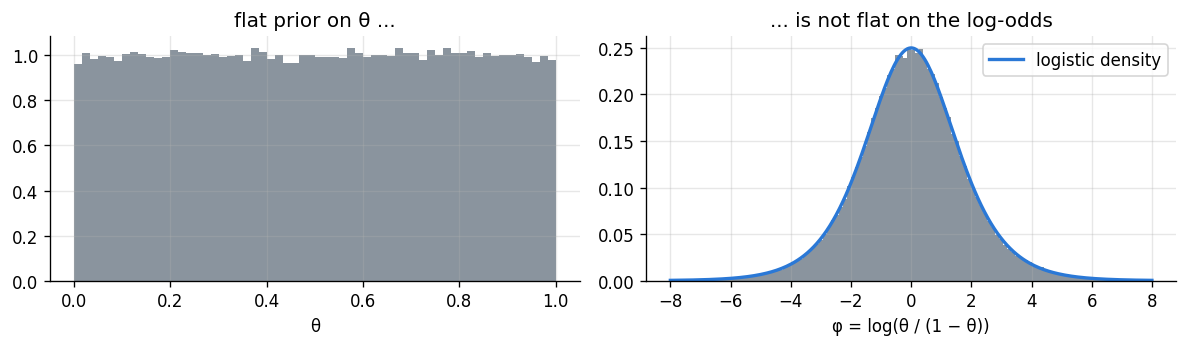

In [3]:
theta = rng.random(200_000)
phi = np.log(theta / (1 - theta))
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].hist(theta, bins=60, density=True, color=PRIOR)
ax[0].set_title("flat prior on θ ..."); ax[0].set_xlabel("θ")
ax[1].hist(phi, bins=120, range=(-8, 8), density=True, color=PRIOR)
g = np.linspace(-8, 8, 300)
ax[1].plot(g, np.exp(g) / (1 + np.exp(g)) ** 2, color=POST, lw=2, label="logistic density")
ax[1].set_title("... is not flat on the log-odds"); ax[1].set_xlabel("φ = log(θ / (1 − θ))"); ax[1].legend()
plt.tight_layout(); plt.show()

## 5. Jeffreys priors

Jeffreys proposed a rule that gives the same answer whichever parameterisation you
start from [1]:
$$ \boxed{\;p(\theta)\propto\sqrt{I(\theta)}\;},\qquad
   I(\theta) = -\,\mathbb E\!\left[\frac{\partial^2}{\partial\theta^2}\log f(y\mid\theta)\ \middle|\ \theta\right], $$
where $I(\theta)$ is the **Fisher information** of one observation, the expected
version of the curvature we used for standard errors in chapter 03.

**Why it is invariant.** If $\phi$ is a smooth one-to-one function of $\theta$, the
chain rule gives $I_\phi(\phi) = I_\theta(\theta)\,(\mathrm d\theta/\mathrm d\phi)^2$, so
$\sqrt{I_\phi(\phi)} = \sqrt{I_\theta(\theta)}\,|\mathrm d\theta/\mathrm d\phi|$. That is
exactly the change-of-variables rule for densities: computing Jeffreys' prior for
$\theta$ and transforming it gives Jeffreys' prior for $\phi$.

**Examples.**

- **Bernoulli.** $\log f = y\log\theta+(1-y)\log(1-\theta)$, so
  $-\partial^2_\theta\log f = y/\theta^2+(1-y)/(1-\theta)^2$ with expectation
  $1/\theta+1/(1-\theta) = 1/(\theta(1-\theta))$. Jeffreys' prior is
  $\theta^{-1/2}(1-\theta)^{-1/2}$: **Beta(1/2, 1/2)**, halfway between flat and Haldane.
- **Poisson.** $I(\lambda) = 1/\lambda$, so $p(\lambda)\propto\lambda^{-1/2}$ (improper).
- **Normal mean** ($\sigma$ known): $I(\mu) = 1/\sigma^2$ is constant, so the flat prior.
- **Normal scale** ($\mu$ known): $p(\sigma)\propto1/\sigma$, equivalently $p(\sigma^2)\propto1/\sigma^2$.

Jeffreys priors often have good frequentist properties too. The 95% equal-tailed
credible interval under Beta(1/2, 1/2) is a well-regarded interval for a binomial
proportion [5]. The code computes its exact coverage with the same method as in
chapter 03 and compares it with the Wald interval that failed there.

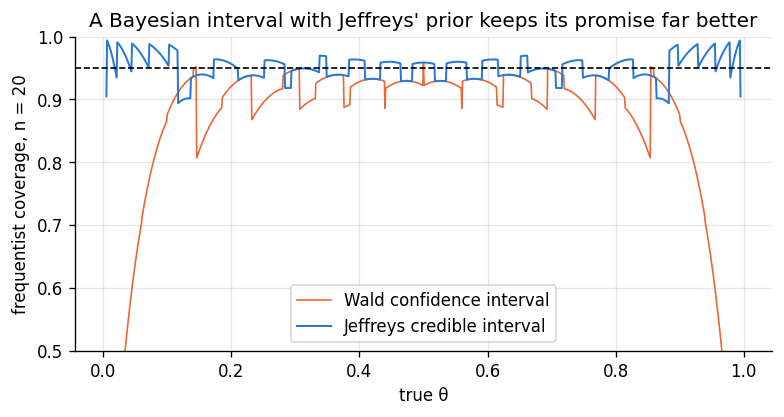

at θ = 0.05: Wald 0.639, Jeffreys 0.984


In [4]:
def coverage(theta, n, lo, hi):
    ys = np.arange(n + 1)
    inside = (lo <= theta) & (theta <= hi)
    return stats.binom.pmf(ys, n, theta)[inside].sum()

n = 20
ys = np.arange(n + 1)
t_hat = ys / n
wald = (t_hat - 1.96 * np.sqrt(t_hat * (1 - t_hat) / n), t_hat + 1.96 * np.sqrt(t_hat * (1 - t_hat) / n))
jeff = (stats.beta.ppf(0.025, ys + 0.5, n - ys + 0.5), stats.beta.ppf(0.975, ys + 0.5, n - ys + 0.5))

grid = np.linspace(0.005, 0.995, 991)
plt.plot(grid, [coverage(t, n, *wald) for t in grid], color=LIK, lw=1, label="Wald confidence interval")
plt.plot(grid, [coverage(t, n, *jeff) for t in grid], color=POST, lw=1.2, label="Jeffreys credible interval")
plt.axhline(0.95, color="k", ls="--", lw=1); plt.ylim(0.5, 1.0)
plt.xlabel("true θ"); plt.ylabel("frequentist coverage, n = 20")
plt.title("A Bayesian interval with Jeffreys' prior keeps its promise far better")
plt.legend(); plt.show()
print(f"at θ = 0.05: Wald {coverage(0.05, n, *wald):.3f}, Jeffreys {coverage(0.05, n, *jeff):.3f}")

Jeffreys' rule is less attractive with several parameters, where it can give odd
answers, and "reference priors" and related formal rules refine it [6].

## 6. Prior predictive checks and weakly informative priors

A prior that looks harmless on the parameter can imply absurd data. The **prior
predictive** distribution (chapter 04) makes this visible: simulate a parameter from
the prior, then data from the likelihood, and ask whether the result looks like
anything the real world could produce.

Take the café complaints of chapter 05. A common "vague" choice for a Poisson rate is
Gamma$(0.001, 0.001)$: mean 1, variance 1000. The prior predictive for a day's
complaints shows what it really believes: most of the time essentially zero
complaints, and occasionally hundreds. A **weakly informative** prior such as
Gamma$(2, 0.5)$ (mean 4, most mass below about 12) still lets the data speak but rules
out the absurd [7].

In [5]:
for name, (a0, b0) in {"'vague' Gamma(0.001, 0.001)": (0.001, 0.001),
                        "weakly informative Gamma(2, 0.5)": (2.0, 0.5)}.items():
    lam = rng.gamma(a0, 1 / b0, size=100_000)
    daily = rng.poisson(lam)
    q = np.quantile(daily, [0.5, 0.9, 0.99, 0.999])
    print(f"{name:<34} P(0 complaints) = {np.mean(daily == 0):.2f};  median, 90%, 99%, 99.9% quantiles: {q.astype(int)}")

'vague' Gamma(0.001, 0.001)        P(0 complaints) = 0.99;  median, 90%, 99%, 99.9% quantiles: [  0   0   0 267]
weakly informative Gamma(2, 0.5)   P(0 complaints) = 0.11;  median, 90%, 99%, 99.9% quantiles: [ 3  9 15 21]


## 7. Sensitivity analysis

Different reasonable priors should be tried, and the conclusions reported alongside
how much they move. Here are five priors for a proportion, updated with 3 successes
out of 10 trials and with 60 out of 200 (the same 30% rate, twenty times the data).


3/10 observed:
  flat Beta(1,1)       posterior mean 0.333, 95% interval (0.109, 0.610)
  Jeffreys Beta(½,½)   posterior mean 0.318, 95% interval (0.093, 0.606)
  Beta(5,5)            posterior mean 0.400, 95% interval (0.203, 0.616)
  Beta(2,8)            posterior mean 0.250, 95% interval (0.091, 0.456)
  Beta(20,20)          posterior mean 0.460, 95% interval (0.325, 0.598)

60/200 observed:
  flat Beta(1,1)       posterior mean 0.302, 95% interval (0.241, 0.367)
  Jeffreys Beta(½,½)   posterior mean 0.301, 95% interval (0.240, 0.366)
  Beta(5,5)            posterior mean 0.310, 95% interval (0.249, 0.374)
  Beta(2,8)            posterior mean 0.295, 95% interval (0.236, 0.359)
  Beta(20,20)          posterior mean 0.333, 95% interval (0.275, 0.394)


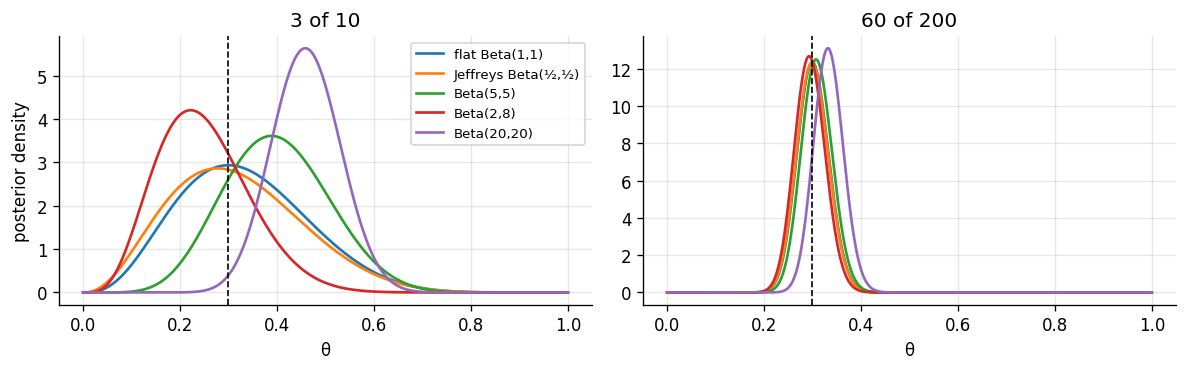

In [6]:
priors = {"flat Beta(1,1)": (1, 1), "Jeffreys Beta(½,½)": (0.5, 0.5), "Beta(5,5)": (5, 5),
          "Beta(2,8)": (2, 8), "Beta(20,20)": (20, 20)}
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2), sharey=False)
t = np.linspace(0.001, 0.999, 999)
for a, (y, n) in zip(ax, [(3, 10), (60, 200)]):
    print(f"\n{y}/{n} observed:")
    for name, (a0, b0) in priors.items():
        post = stats.beta(a0 + y, b0 + n - y)
        a.plot(t, post.pdf(t), lw=1.6, label=name)
        lo, hi = post.ppf([0.025, 0.975])
        print(f"  {name:<20} posterior mean {post.mean():.3f}, 95% interval ({lo:.3f}, {hi:.3f})")
    a.axvline(y / n, color="k", ls="--", lw=1); a.set_xlabel("θ"); a.set_title(f"{y} of {n}")
ax[0].legend(fontsize=8); ax[0].set_ylabel("posterior density")
plt.tight_layout(); plt.show()

With 10 observations the choice of prior visibly changes the answer: the Beta(20, 20)
prior, worth 40 observations, drags the estimate towards 0.5. With 200 observations
all five posteriors nearly coincide. When the data are weak, say so and show the
sensitivity; when they are strong, the prior is a detail.

### Exercises

1. Elicit a gamma prior for the number of emails you receive per hour from two
   statements of your own (a typical value and an upper bound you would be surprised
   to exceed). Check its prior predictive distribution for a working day.
2. Show that the posterior under the improper prior $p(\sigma^2)\propto1/\sigma^2$ with known
   mean $\mu$ is InvGamma$\big(n/2,\ \tfrac12\sum_i(y_i-\mu)^2\big)$, and find the smallest $n$
   for which it is proper.
3. Derive Jeffreys' prior for the rate $\lambda$ of an exponential distribution. Is the
   resulting posterior proper after one observation?
4. Verify numerically that transforming Jeffreys' Beta(1/2, 1/2) prior to the log-odds
   scale gives $\sqrt{I_\phi(\phi)}$ computed directly for the Bernoulli in log-odds form.
5. Add the flat-prior Beta$(y+1, n-y+1)$ credible interval to the coverage plot. How
   does it compare with Jeffreys?
6. For the A/B test of chapter 05, run a sensitivity analysis of $P(\theta_B>\theta_A)$
   over a range of shared beta priors. Is the conclusion robust?

## References

1. H. Jeffreys. *An invariant form for the prior probability in estimation problems.* Proceedings of the Royal Society A, 186:453-461, 1946. doi:10.1098/rspa.1946.0056
2. H. Jeffreys. *Theory of Probability*, 3rd ed. Oxford University Press, 1961.
3. R. E. Kass, L. Wasserman. *The selection of prior distributions by formal rules.* Journal of the American Statistical Association, 91(435):1343-1370, 1996. doi:10.1080/01621459.1996.10477003
4. A. O'Hagan, C. E. Buck, A. Daneshkhah, J. R. Eiser, P. H. Garthwaite, D. J. Jenkinson, J. E. Oakley, T. Rakow. *Uncertain Judgements: Eliciting Experts' Probabilities.* Wiley, 2006.
5. L. D. Brown, T. T. Cai, A. DasGupta. *Interval Estimation for a Binomial Proportion.* Statistical Science, 16(2):101-133, 2001. doi:10.1214/ss/1009213286
6. J. M. Bernardo. *Reference posterior distributions for Bayesian inference.* Journal of the Royal Statistical Society B, 41(2):113-147, 1979.
7. A. Gelman. *Prior distributions for variance parameters in hierarchical models.* Bayesian Analysis, 1(3):515-534, 2006. doi:10.1214/06-BA117A
8. J. Gabry, D. Simpson, A. Vehtari, M. Betancourt, A. Gelman. *Visualization in Bayesian workflow.* Journal of the Royal Statistical Society A, 182(2):389-402, 2019. doi:10.1111/rssa.12378